# Random Forest Classification

The random forest classifier is a set of decision trees from a randomly selected subset of the training set. It aggregates the votes from different decision trees to decide the final class of the test object.

In [7]:
#Rungphailin Siamphupong 

import numpy as np
import pandas as pd                                     #Import library pandas for import csv file
from sklearn.model_selection import train_test_split    #use for split data to train and test model
from sklearn.ensemble import RandomForestClassifier     #Use for do Random Forest

read csv file

In [8]:
df =pd.read_csv('diabetes.csv')         #import diabets csv file
df                                      #show data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [9]:
df['Outcome'].value_counts()       # (disease =1), (no disease =0)

0    500
1    268
Name: Outcome, dtype: int64

String to number

In [11]:
from sklearn import preprocessing                                    # import library to convert string to number in column 'Outcome'
le = preprocessing.LabelEncoder()
# Converting string labels into numbers.
outcome_encoded = le.fit_transform(df['Outcome'])                    # (disease =1), (no disease =0)
df_encoded = pd.DataFrame(outcome_encoded, columns=['Outcome'])      # Change data in to pandas form and keep in variable df_encoded

new_df = df                                                          # copy df data to new_df
new_df['Outcome'] = df_encoded                                       # Put the numeric values from df_encoded into the column 'Outcome'
new_df                                                               # show output

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


X = new_df that cut 'Outcome' column

y = dataframe that has only 'Outcome' column

In [12]:
X = new_df.drop('Outcome', axis = 1)          # X = new_df that cut 'Outcome' column
y = new_df['Outcome']                         # y = dataframe that has only 'Outcome' column

Show X

In [13]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


Show y

In [14]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

    train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

*arrayssequence of indexables with same length / shape[0]
Allowed inputs are lists, numpy arrays, scipy-sparse matrices or pandas dataframes.

test_sizefloat or int, default=None
If float, should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the test split. If int, represents the absolute number of test samples. If None, the value is set to the complement of the train size. If train_size is also None, it will be set to 0.25.

train_sizefloat or int, default=None
If float, should be between 0.0 and 1.0 and represent the proportion of the dataset to include in the train split. If int, represents the absolute number of train samples. If None, the value is automatically set to the complement of the test size.

random_stateint, RandomState instance or None, default=None
Controls the shuffling applied to the data before applying the split. Pass an int for reproducible output across multiple function calls. See Glossary.

shufflebool, default=True
Whether or not to shuffle the data before splitting. If shuffle=False then stratify must be None.

stratifyarray-like, default=None
If not None, data is split in a stratified fashion, using this as the class labels.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 6)    # split data train 60% and test 40%


Train and fit the model: random forest classifier

In [16]:
df[:] = np.nan_to_num(df)  # Replace NaN with zero and infinity with large finite numbers

In [17]:
X = np.nan_to_num(X)

In [18]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
rdf_clf = RandomForestClassifier()

In [20]:
rdf_clf.fit(X_train, y_train)

RandomForestClassifier()

Find model accuracy

In [21]:
# Evaluate the model's accuracy
print("Train set accuracy = " + str(rdf_clf.score(X_train, y_train)))
print("Test set accuracy = " + str(rdf_clf.score(X_test, y_test)))

Train set accuracy = 1.0
Test set accuracy = 0.75


predict y from x test

In [22]:
y_predicted = rdf_clf.predict(X_test)
print(y_predicted)

[0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0
 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 1 0
 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0
 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1
 0 1 1 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0
 0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 1
 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0
 1 0 1 1 1 0 0 1 0 1 1 0]


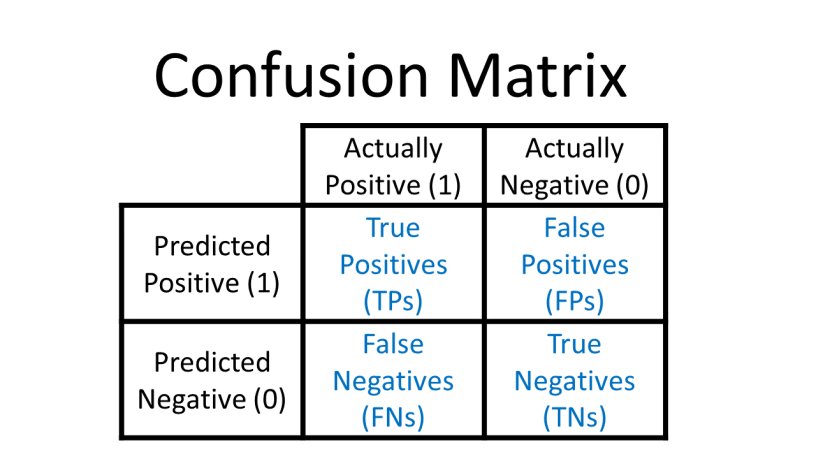


TP / True Positive: when a case was positive and predicted positive

TN / True Negative: when a case was negative and predicted negative

FN / False Negative: when a case was positive but predicted negative

FP / False Positive: when a case was negative but predicted positive

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[168,  40],
       [ 37,  63]], dtype=int64)

Precision is the ability of a classifier not to label an instance positive that is actually negative. For each class it is defined as the ratio of true positives to the sum of true and false positives.
                
                Precision = TP/(TP + FP)

Recall is the ability of a classifier to find all positive instances. For each class it is defined as the ratio of true positives to the sum of true positives and false negatives.
                
                Recall = TP/(TP+FN)

The F1 score is a weighted harmonic mean of precision and recall such that the best score is 1.0 and the worst is 0.0. Generally speaking, F1 scores are lower than accuracy measures as they embed precision and recall into their computation. As a rule of thumb, the weighted average of F1 should be used to compare classifier models, not global accuracy.
                
                F1 Score = 2*(Recall * Precision) / (Recall + Precision)

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_predicted, y_test))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       205
           1       0.63      0.61      0.62       103

    accuracy                           0.75       308
   macro avg       0.72      0.72      0.72       308
weighted avg       0.75      0.75      0.75       308

